<a href="https://colab.research.google.com/github/yyalexlee/EastAsiaClimateExtremes/blob/main/CODES/Weekly_Extreme_Statistics_and_Visualization_ECMWF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Extreme Comparison on Model data (ECMWF) with Observational data (ERA5)**



*   Updated: July 8 2026
*   Team: ART (AI-based Prediction Research and Technology, APEC Climate Center)
*   Contact: Uran Chung (uchung@apcc21.org)





> This exercise is designed to compare the performance of **ERA5 reanalysis data with two comparisons**: the **ECMWF S2S Hindcast forecast** (ver.2016 and 2024). **(1)** **the frequency of abnormally high temperatures** (AHT) over three weeks and **(2)** **the three-week AHT time series** for selected locations (e.g., **Seoul**) for a representative year (e.g., 2023).



*   Model Data: Directory **3.Weekly_ECMWFhcst**
*   Observation Data: Directory **2.Weekly_ERA5**



**You will need to mount your Google Drive to practice.**

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


* **Cartopy** requires a declaration after **installation**, so it is installed first.

In [2]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 70.6 MB/s eta 0:00:00


*   Declare necessary libraries


In [3]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from dask.diagnostics import ProgressBar


*   Set **Paths** work on



In [4]:
# PATH: ECMWF and ERA5 data
base_dir_ecmwf = '/content/gdrive/My Drive/Colab Notebooks/APCC/Data/3.Weekly_ECMWFhcst'
base_dir_era5 = '/content/gdrive/My Drive/Colab Notebooks/APCC/Data/2.Weekly_ERA5'

In [5]:
# PATH: Output
Output_Figures = '/content/gdrive/My Drive/Colab Notebooks/APCC/Output/Figures'

In [6]:
Path(Output_Figures).mkdir(parents=True, exist_ok=True)

The **ECMWF-hindcast NetCDF data** to be loaded now was reconstructed from ECMWF Hindcast versions 2016 and 2024. For each forecast initialization date, data corresponding to lead week 3 (days 15–21 after initialization) were extracted and reorganized into daily records. Constructed by calculating the daily **90th percentile climatological** values based on the forecast initialization dates for each ECMWF Hindcast version.

> Time series changes of extreme values ​​exceeding a threshold for the annual average frequency and a specific year (e.g., 2023) of a target point by selecting only variables through user variable definition

> First, compare the **Frequency** of Abnormal High Temperatures (AHT)

In [7]:
# User variable settings
VAR_TYPE = "T2M"  # Select one of "T2M", "TP", "SST"

# tp & PREC
VAR_KEY = "tp" if VAR_TYPE.upper() in ["tp", "PREC"] else VAR_TYPE.upper()

In [8]:
# Mapping of filenames by variable and nc internal variable name dictionaries
config = {"T2M": {"ec16_file": f"{base_dir_ecmwf}/v2016_ECMWF_hindcast_T2M_weekly.nc",
            "ec24_file": f"{base_dir_ecmwf}/v2024_ECMWF_hindcast_T2M_weekly.nc",
            "ec16_thr":  f"{base_dir_ecmwf}/v2016_ECMWF_hindcast_T2M_w3_clim90th.nc",
            "ec24_thr":  f"{base_dir_ecmwf}/v2024_ECMWF_hindcast_T2M_w3_clim90th.nc",
            "era_file":  f"{base_dir_era5}/ERA5_7day_rolling_T2m_1940_2024.nc",
            "thr_file":  f"{base_dir_era5}/T2m_thresholds_dataset_1991_2020.nc",
            "thr90_file": f"{base_dir_era5}/T2m_thresholds_dataset_1996_2015.nc",
            "thr00_file": f"{base_dir_era5}/T2m_thresholds_dataset_2004_2023.nc",
            "var_ec": "t2m",
            "var_ec_thr": "t2m_clim90th",
            "var_era": "t2m_7day",
            "var_era_thr": "clim_90th",
            "unit": "°C",
            "need_degC_convert": True},
    "TP": {"ec16_file": f"{base_dir_ecmwf}/v2016_ECMWF_hindcast_TP_weekly.nc",
           "ec24_file": f"{base_dir_ecmwf}/v2024_ECMWF_hindcast_TP_weekly.nc",
           "ec16_thr":  f"{base_dir_ecmwf}/v2016_ECMWF_hindcast_PREC_w3_clim90th.nc",
           "ec24_thr":  f"{base_dir_ecmwf}/v2024_ECMWF_hindcast_PREC_w3_clim90th.nc",
           "era_file":  f"{base_dir_era5}/ERA5_7day_rolling_TP_1940_2024.nc",
           "thr_file":  f"{base_dir_era5}/TP_thresholds_dataset_1991_2020.nc",
           "thr90_file": f"{base_dir_era5}/TP_thresholds_dataset_1996_2015.nc",
           "thr00_file": f"{base_dir_era5}/TP_thresholds_dataset_2004_2023.nc",
           "var_ec": "tp",
           "var_ec_thr": "tp_clim90th",
           "var_era": "tp_7day",
           "var_era_thr": "clim_90th",
           "unit": "mm",
           "need_degC_convert": False},
    "SST": {"ec16_file": f"{base_dir_ecmwf}/v2016_ECMWF_hindcast_SST_weekly.nc",
            "ec24_file": f"{base_dir_ecmwf}/v2024_ECMWF_hindcast_SST_weekly.nc",
            "ec16_thr":  f"{base_dir_ecmwf}/v2016_ECMWF_hindcast_SST_w3_clim90th.nc",
            "ec24_thr":  f"{base_dir_ecmwf}/v2024_ECMWF_hindcast_SST_w3_clim90th.nc",
            "era_file":  f"{base_dir_era5}/ERA5_7day_rolling_SST_1940_2024.nc",
            "thr_file":  f"{base_dir_era5}/SST_thresholds_dataset_1991_2020.nc",
            "thr90_file": f"{base_dir_era5}/SST_thresholds_dataset_1996_2015.nc",
            "thr00_file": f"{base_dir_era5}/SST_thresholds_dataset_2004_2023.nc",
            "var_ec": "sst",
            "var_ec_thr": "sst_clim90th",
            "var_era": "sst_7day",
            "var_era_thr": "clim_90th",
            "unit": "°C","need_degC_convert": True}}

In [9]:
cfg = config[VAR_KEY]

In [10]:
out_figfile = os.path.join(Output_Figures, f"Weekly_Mean_Annual_Frequency90_ERA5_ECMWF_{VAR_KEY}.png")
out_figfile2 = os.path.join(Output_Figures, f"Weekly_Mean_Annual_Frequency90_1996_2023_ERA5_ECMWF{VAR_KEY}.png")
out_figfile3 = os.path.join(Output_Figures, f"Weekly_AHT_ECMWF_v2016_v2024_timeseries_P90_{VAR_KEY}.png")

*   Load data  & variables

In [11]:
# Data Loading and Initial Processing
ds16_week = xr.open_dataset(cfg["ec16_file"])
ds24_week = xr.open_dataset(cfg["ec24_file"])

thr16 = xr.open_dataset(cfg["ec16_thr"])
thr24 = xr.open_dataset(cfg["ec24_thr"])

ds = xr.open_dataset(cfg["era_file"])
thr = xr.open_dataset(cfg["thr_file"])
thr90 = xr.open_dataset(cfg["thr90_file"])
thr00 = xr.open_dataset(cfg["thr00_file"])

In [12]:
# Extract ERA5 comparison period
ds_sub90 = ds.sel(time=slice("1996", "2015"))
ds_sub00 = ds.sel(time=slice("2004", "2023"))

In [13]:
# Matching coordinate names (lat/lon -> latitude/longitude)
def rename_coords(dataset):
    rename_dict = {}
    if "lat" in dataset.coords or "lat" in dataset.dims:
        rename_dict["lat"] = "latitude"
    if "lon" in dataset.coords or "lon" in dataset.dims:
        rename_dict["lon"] = "longitude"
    return dataset.rename(rename_dict) if rename_dict else dataset

In [14]:
era = rename_coords(ds)
era90 = rename_coords(ds_sub90)
era00 = rename_coords(ds_sub00)

thr = rename_coords(thr)
thr90 = rename_coords(thr90)
thr00 = rename_coords(thr00)

In [15]:
# remove leap year
def remove_leap(ds):
    time = ds.time.to_index()
    mask = ~((time.month == 2) & (time.day == 29))
    return ds.isel(time=mask)

In [16]:
ds16_week = remove_leap(ds16_week)
ds24_week = remove_leap(ds24_week)

era = remove_leap(era)
era90 = remove_leap(era90)
era00 = remove_leap(era00)

In [17]:
# Calendar mapping function: Mapping the threshold dataset (doy 1~366) based on the actual dates (month, day) of the 7-day moving average data
def map_climatology(data_series, threshold_clim):
    clim_full = threshold_clim.reindex(doy=np.arange(1, 367), method="nearest")
    doy = data_series.time.dt.dayofyear
    aligned = clim_full.sel(doy=doy).transpose("time", "latitude", "longitude")
    return aligned

> *   **Calculate** Extreme Statistics:
> 1. Extreme **Frequency per Year** (ERA5, v2016, v2024)

In [18]:
# ECMWF v2016
if isinstance(ds16_week, xr.Dataset):
    v16_week = ds16_week[cfg["var_ec"]] if cfg["var_ec"] in ds16_week else ds16_week[list(ds16_week.data_vars)[0]]
else:
    v16_week = ds16_week

thr16_sub = thr16[cfg["var_ec_thr"]].sel(latitude=v16_week.latitude, longitude=v16_week.longitude, method="nearest")
thr16_aligned = map_climatology(v16_week, thr16_sub)
v16_exceed = (v16_week > thr16_aligned).astype(np.int16)
v16_freq = v16_exceed.groupby("time.year").sum("time").mean("year")

In [19]:
# ECMWF v2024
if isinstance(ds24_week, xr.Dataset):
    v24_week = ds24_week[cfg["var_ec"]] if cfg["var_ec"] in ds24_week else ds24_week[list(ds24_week.data_vars)[0]]
else:
    v24_week = ds24_week

thr24_sub = thr24[cfg["var_ec_thr"]].sel(latitude=v24_week.latitude, longitude=v24_week.longitude, method="nearest")
thr24_aligned = map_climatology(v24_week, thr24_sub)
v24_exceed = (v24_week > thr24_aligned).astype(np.int16)
v24_freq = v24_exceed.groupby("time.year").sum("time").mean("year")

In [20]:
# ERA5
era_data = era[cfg["var_era"]].sel(time=era[cfg["var_era"]].time.dt.dayofweek == 0)
era90_data = era90[cfg["var_era"]].sel(time=era90[cfg["var_era"]].time.dt.dayofweek == 0)
era00_data = era00[cfg["var_era"]].sel(time=era00[cfg["var_era"]].time.dt.dayofweek == 0)

In [21]:
thr_era_sub = thr[cfg["var_era_thr"]].sel(latitude=era_data.latitude, longitude=era_data.longitude, method="nearest")
thr_era90_sub = thr90[cfg["var_era_thr"]].sel(latitude=era90_data.latitude, longitude=era90_data.longitude, method="nearest")
thr_era00_sub = thr00[cfg["var_era_thr"]].sel(latitude=era00_data.latitude, longitude=era00_data.longitude, method="nearest")

In [22]:
# Unit conversion (Kelvin -> Celsius)
if cfg["need_degC_convert"]:
    thr_era_sub_proc = thr_era_sub - 273.15
    thr_era90_sub_proc = thr_era90_sub - 273.15
    thr_era00_sub_proc = thr_era00_sub - 273.15
else:
    thr_era_sub_proc = thr_era_sub
    thr_era90_sub_proc = thr_era90_sub
    thr_era00_sub_proc = thr_era00_sub

In [23]:
thr_era_aligned = map_climatology(era_data, thr_era_sub_proc)
thr_era90_aligned = map_climatology(era90_data, thr_era90_sub_proc)
thr_era00_aligned = map_climatology(era00_data, thr_era00_sub_proc)

In [24]:
era_exceed = (era_data > thr_era_aligned).astype(np.int16)
era_freq = era_exceed.groupby("time.year").sum("time").mean("year")

In [25]:
era90_exceed = (era90_data > thr_era90_aligned).astype(np.int16)
era90_freq = era90_exceed.groupby("time.year").sum("time").mean("year")

era00_exceed = (era00_data > thr_era00_aligned).astype(np.int16)
era00_freq = era00_exceed.groupby("time.year").sum("time").mean("year")

> Using Long-term period of ERA5 (1940-2024), **ERA5 (1996–2015)**, **ERA5 (2004-2023)** and **ECMWF S2S model data (1996–2015: ver.2016, 2004–2023: ver.2024)**, we calculate the frequency of **abnormally high temperatures (AHT)** exceeding the climatological mean of the version-specific **90th percentile threshold** at **week 3** and present the results graphically.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


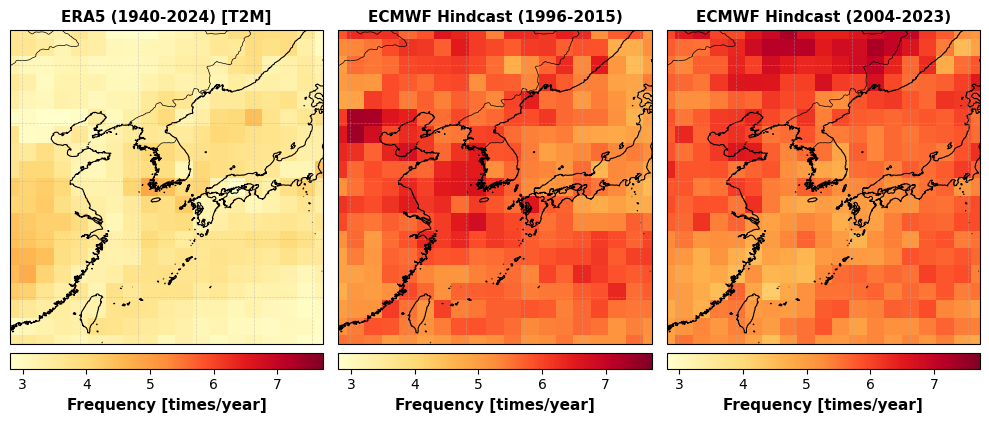

In [26]:
# Plotting
fig = plt.figure(figsize=(10, 5))
titles = [f"ERA5 (1940-2024) [{VAR_KEY}]",
          f"ECMWF Hindcast (1996-2015)", f"ECMWF Hindcast (2004-2023)"]
datasets = [era_freq, v16_freq, v24_freq]

global_vmin = min(float(d.quantile(0.01)) for d in datasets)
global_vmax = max(float(d.quantile(0.99)) for d in datasets)

for i, data in enumerate(datasets):
    ax = plt.subplot(1, 3, i+1, projection=ccrs.PlateCarree())
    ax.set_extent([114, 141, 21, 48], ccrs.PlateCarree())
    ax.coastlines("10m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    gl = ax.gridlines(draw_labels=False, linewidth=0.5, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    pcm = data.plot(
        ax=ax,
        cmap="YlOrRd" if VAR_KEY != "TP" else "Blues",
        vmin=global_vmin,
        vmax=global_vmax,
        extend="both",
        transform=ccrs.PlateCarree(),
        add_colorbar=False)

    cbar = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.02)
    cbar.set_label("Frequency [times/year]", fontsize=11, fontweight="bold")
    ax.set_title(titles[i], fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(out_figfile, dpi=300, bbox_inches="tight")
plt.show()

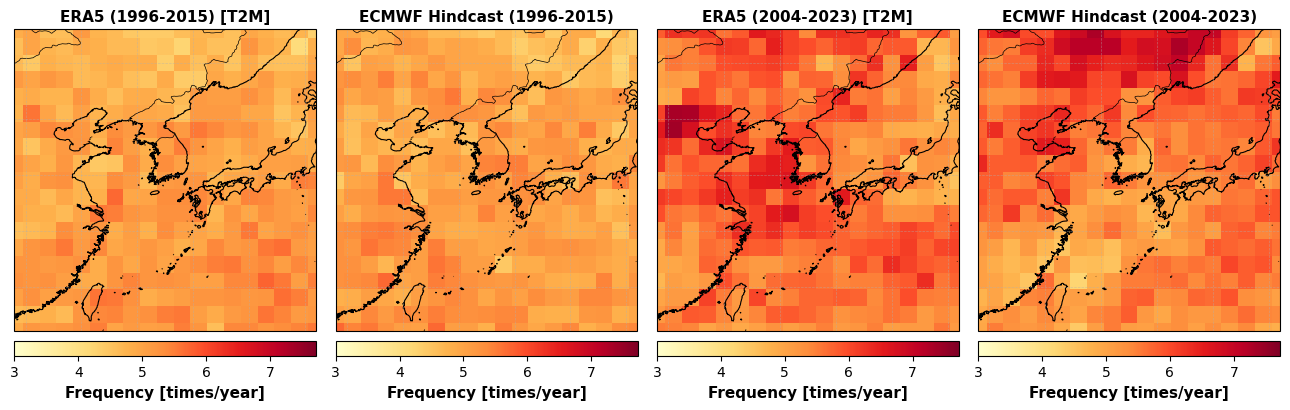

In [27]:
# Plotting 2
fig = plt.figure(figsize=(13, 5))
titles = [f"ERA5 (1996-2015) [{VAR_KEY}]", f"ECMWF Hindcast (1996-2015)",
          f"ERA5 (2004-2023) [{VAR_KEY}]", f"ECMWF Hindcast (2004-2023)"]
datasets = [era90_freq, era00_freq, v16_freq, v24_freq]

global_vmin = min(float(d.quantile(0.01)) for d in datasets)
global_vmax = max(float(d.quantile(0.99)) for d in datasets)

for i, data in enumerate(datasets):
    ax = plt.subplot(1, 4, i+1, projection=ccrs.PlateCarree())
    ax.set_extent([114, 141, 21, 48], ccrs.PlateCarree())
    ax.coastlines("10m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    gl = ax.gridlines(draw_labels=False, linewidth=0.5, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    pcm = data.plot(
        ax=ax,
        cmap="YlOrRd" if VAR_KEY != "TP" else "Blues",
        vmin=global_vmin,
        vmax=global_vmax,
        extend="both",
        transform=ccrs.PlateCarree(),
        add_colorbar=False)

    cbar = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.02)
    cbar.set_label("Frequency [times/year]", fontsize=11, fontweight="bold")
    ax.set_title(titles[i], fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(out_figfile2, dpi=300, bbox_inches="tight")
plt.show()

----------------------------------------------------------------------------



---



> Comparison of **the Week 3 time series of abnormalously high temperatures (AHT) in 2023** from ECMWF S2S (ver. 2024) against the ERA5 threshold climatology (2004-2023) at the target location (Seoul).

Setting **the coordinates of the Seoul** point to view the time series change of of the 2023 ECMWF abnormal high temperatures (AHT) relative to the ERA5 at the Seoul.

In [28]:
# Target point
target_lat = 36.0  #37.57142
target_lon = 127.5 #126.96582

- Need to convert Kelvin to Celsius

In [29]:
# K -> C
if cfg["need_degC_convert"]:
    v16_week_proc = v16_week - 273.15
    thr16_aligned_proc = thr16_aligned - 273.15
    v24_week_proc = v24_week - 273.15
    thr24_aligned_proc = thr24_aligned - 273.15
else:
    v16_week_proc = v16_week
    thr16_aligned_proc = thr16_aligned
    v24_week_proc = v24_week
    thr24_aligned_proc = thr24_aligned

- In order to compare the time series change of AHT in **2023 of V2024** with the Normal year
- Calculate and Plot

In [31]:
# --- [Right: Subplot data: V2024 & 2023] ---
v24_week_pt = v24_week_proc.sel(latitude=target_lat, longitude=target_lon, method="nearest")
era00_data_pt = era00_data.sel(latitude=target_lat, longitude=target_lon, method="nearest")
thr24_aligned_pt = thr24_aligned_proc.sel(latitude=target_lat, longitude=target_lon, method="nearest")
thr_era00_aligned_pt = thr_era00_aligned.sel(latitude=target_lat, longitude=target_lon, method="nearest")

common_pt_time24 = v24_week_pt.time
era00_data_pt = era00_data_pt.reindex(time=common_pt_time24, method="nearest")
thr_era00_aligned_pt = thr_era00_aligned_pt.reindex(time=common_pt_time24, method="nearest")

v24_2023 = v24_week_pt.sel(time="2023")
era5_2023 = era00_data_pt.sel(time="2023").reindex_like(v24_2023, method="nearest")
thr24_2023 = thr24_aligned_pt.sel(time="2023").reindex_like(v24_2023, method="nearest")
thr_era00_2023 = thr_era00_aligned_pt.sel(time="2023").reindex_like(v24_2023, method="nearest")
doy_2023 = v24_2023.time.dt.dayofyear.values

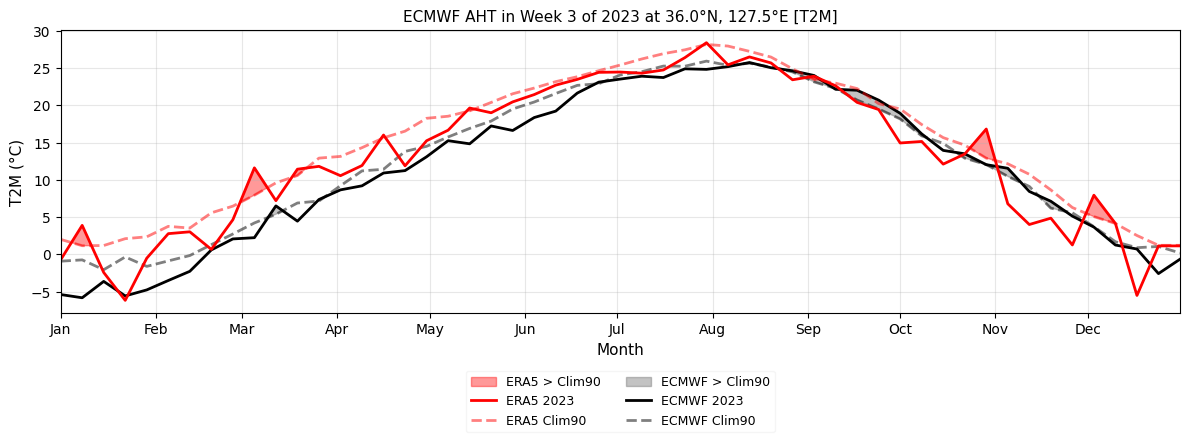

In [32]:
# Timeseries Plot
plt.figure(figsize=(12, 5))

mask_v24 = (v24_2023.values > thr24_2023)
mask_era5 = (era5_2023.values > thr_era00_2023)

h_v24_fill = plt.fill_between(doy_2023, thr24_2023, v24_2023.values, where=mask_v24, interpolate=True, color="dimgray", alpha=0.4)
h_era00_fill = plt.fill_between(doy_2023, thr_era00_2023, era5_2023.values, where=mask_era5, interpolate=True, color="red", alpha=0.4)

# --- Lines: 2023 Actual & Climatology Thresholds ---
l_v24_2023, = plt.plot(doy_2023, v24_2023.values, color="black", linewidth=2, linestyle="-")
l_thr24_2023, = plt.plot(doy_2023, thr24_2023, color="black", linewidth=2, linestyle="--", alpha=0.5)

l_era5_2023, = plt.plot(doy_2023, era5_2023.values, color="red", linewidth=2, linestyle="-")
l_era00_thr_2023, = plt.plot(doy_2023, thr_era00_2023, color="red", linewidth=2, linestyle="--", alpha=0.5)

# --- Lines: 52-Week Mean Climatology (2004-2023) ---
#l_v24_mean, = plt.plot(doy_2023, v24_week_mean.values[:len(doy_2023)], color="grey", linewidth=1.5, linestyle="--") # ":"
#l_era00_mean, = plt.plot(doy_2023, era00_data_mean.values[:len(doy_2023)], color="black", linewidth=1.5, linestyle="--")

handles = [h_era00_fill, l_era5_2023, l_era00_thr_2023, h_v24_fill, l_v24_2023, l_thr24_2023]
labels = ["ERA5 > Clim90", "ERA5 2023", "ERA5 Clim90", "ECMWF > Clim90", "ECMWF 2023", "ECMWF Clim90"]

month_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.xticks(month_ticks, month_labels)
plt.xlim(1, 365)
plt.ylabel(f"{VAR_KEY} ({cfg['unit']})", fontsize=11)
plt.xlabel("Month", fontsize=11)
plt.title(f"ECMWF AHT in Week 3 of 2023 at 36.0°N, 127.5°E [{VAR_KEY}]", fontsize=11)
plt.grid(alpha=0.3)

plt.legend(handles, labels, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18),
           fontsize=9, frameon=True, edgecolor="whitesmoke", facecolor="white", framealpha=1.0)

plt.subplots_adjust(bottom=0.23)
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(out_figfile3, dpi=300, bbox_inches="tight")
plt.show()